In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li
import scipy.stats as stats

In [2]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration X',
    'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

/tmp/ipykernel_502013/1698806942.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [3]:
# totalData[Headers].loc[totalData["Well_down"]==0].apply(np.log1p).hist(figsize=(20,20),bins=200)

In [4]:
mainSeed = 971215
np.random.seed(mainSeed)

PCAHeaders = [str(i) for i in range(0,7)]

pumpList = totalData["Well Run"].unique()

#complexVib = totalData["ESP Vibration X"]+1j*totalData["ESP Vibration Y"]

#totalData["VibMod"] = np.absolute(complexVib)
#totalData["VibArc"] = np.unwrap(np.angle(complexVib))
totalData["Choke Closed"] = 1-totalData["Choke Opening"]
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)

X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

GMM BIC: 3114622.336212627


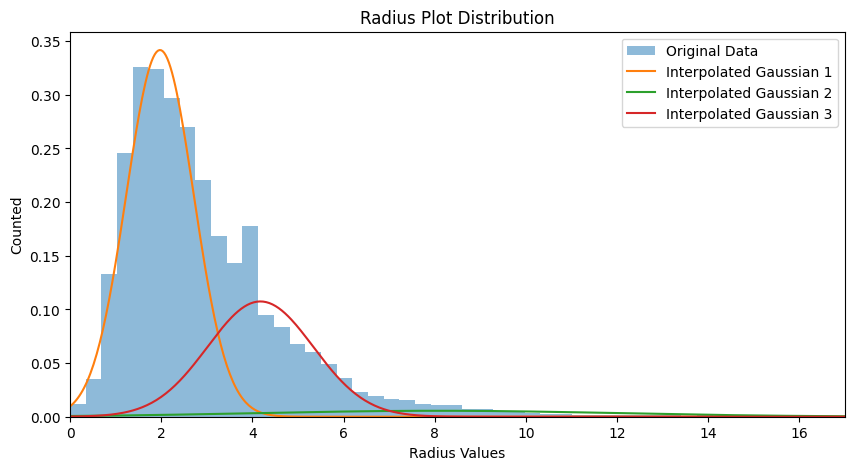

(GaussianMixture(n_components=3, random_state=971215),
 <Figure size 1000x500 with 1 Axes>)

In [5]:
n = 3
radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]

model = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)


li.GaussianMixturePlot(radiusData,model,[
    "Original Data",
    "Interpolated Gaussian",
    "Radius Plot Distribution",
    "Radius Values",
    "Counted"],
    figsize=(10,5))



(0.0, 16.0)

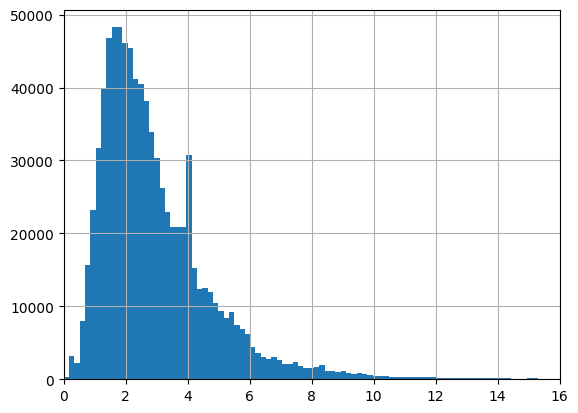

In [6]:
radiusData.hist(bins=200)
plt.xlim([0,16])

In [7]:
radiusData.mean()/(radiusData.std())**2

0.7264234338209442

In [8]:
alpha, mu, beta = stats.gamma.fit(radiusData)
print([alpha,mu,beta])
# data = stats.gamma.rvs(5, loc=0, scale=1/beta, size=1000000)  
# plt.hist(data,bins=200)

[0.769805451350976, -6.450138775912264e-26, 4.713741674532451]


<Axes: >

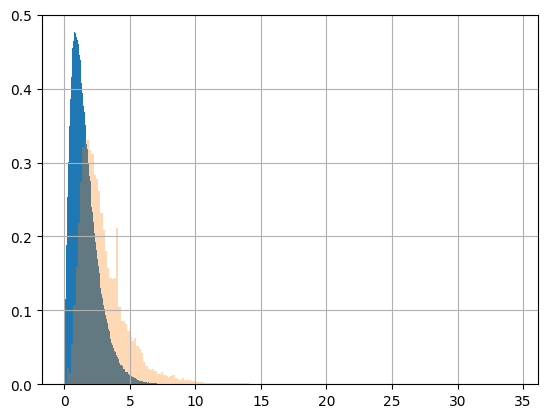

In [9]:
alpha = (radiusData.mean()/radiusData.std())**2
beta = radiusData.mean()/(radiusData.std())**2

data = stats.gamma.rvs(a=alpha,loc=0,scale=beta,size=radiusData.shape[0])

a = plt.hist(data,bins=200,density=True)
radiusData.hist(bins=200,alpha=0.3,density=True)

((array([1.72249956e-03, 2.59002583e-03, 3.21008210e-03, ...,
         1.15536930e+01, 1.19174733e+01, 1.26070023e+01]),
  array([ 0.        ,  0.        ,  0.        , ..., 34.33538094,
         34.38313897, 34.39099667])),
 (1.8432801520509592, 0.08183837748538902, 0.9726664221850979))

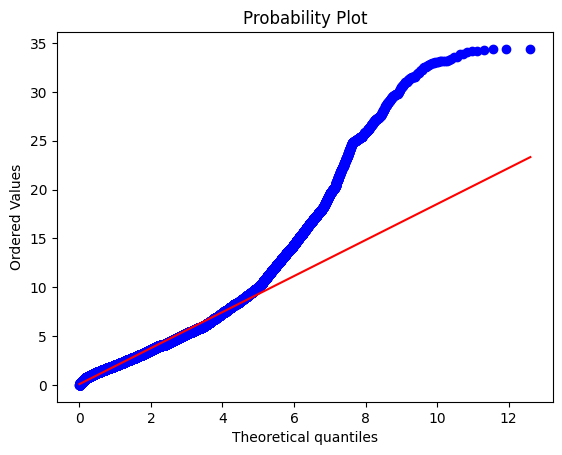

In [10]:

stats.probplot(radiusData, dist="gamma", sparams=(alpha, 0, beta),plot=plt)

KstestResult(statistic=0.3085245203311135, pvalue=0.0, statistic_location=2.447972035390713, statistic_sign=1)


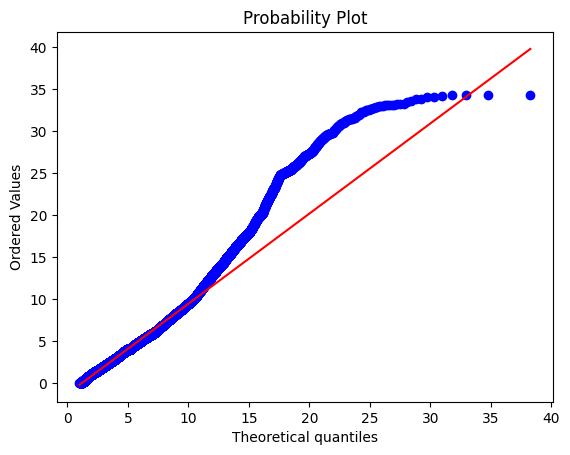

In [11]:

argumentos = stats.lognorm.fit(radiusData+1,method="MLE")
distribuicao = "lognorm"

print(stats.kstest(radiusData, distribuicao, args=argumentos))
a = stats.probplot(radiusData, dist=distribuicao, sparams=argumentos,plot=plt)

KstestResult(statistic=0.012314551775988947, pvalue=4.80576738931508e-112, statistic_location=3.687809935792732, statistic_sign=-1)


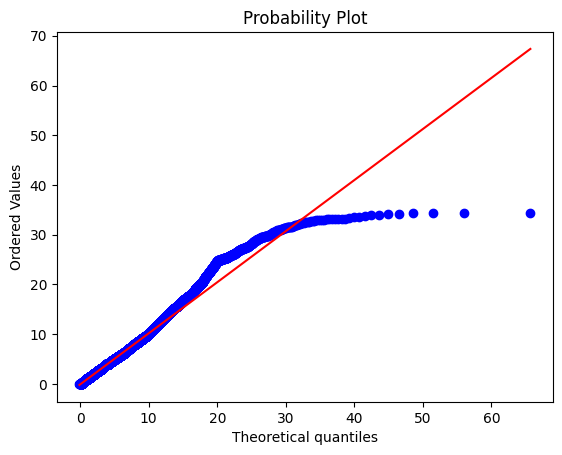

In [12]:
argumentos = stats.betaprime.fit(radiusData)
distribuicao = "betaprime"

print(stats.kstest(radiusData, distribuicao, args=argumentos))
a = stats.probplot(radiusData, dist=distribuicao, sparams=argumentos,plot=plt)

In [13]:

argumentos = stats.lognorm.fit(radiusData+1,method="MM")
distribuicao = "lognorm"
argumentos

(0.7271669451178557, 1.5629867429294317, 1.8674886265395185)

<Axes: >

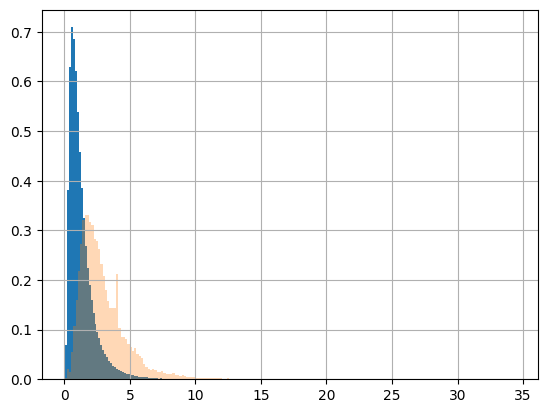

In [14]:
a = plt.hist(stats.lognorm.rvs(argumentos[0],size=radiusData.shape[0]),density=True,bins=200)
radiusData.hist(bins=200,alpha=0.3,density=True)

KstestResult(statistic=0.5856248087652147, pvalue=0.0, statistic_location=1.3062038779181788, statistic_sign=-1)


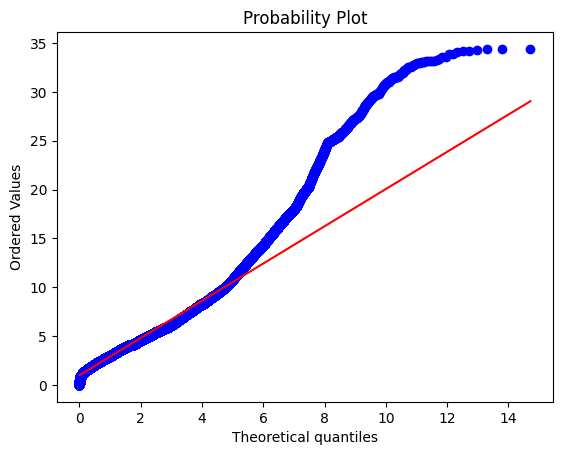

In [52]:
argumentos = stats.gengamma.fit(radiusData,floc=0)
distribuicao = "gengamma"

print(stats.kstest(radiusData, distribuicao, args=argumentos))
a = stats.probplot(radiusData, dist=distribuicao, sparams=argumentos,plot=plt)